<a href="https://colab.research.google.com/github/bhausaheb-pachaptil/Basics-of-Python-/blob/main/AISP%20Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================
# SIMPLE OBJECT CLASSIFICATION
# (Autonomous Driving Example)
# ==============================

import torch
import torch.nn as nn
import torch.optim as optim

# ---------------------------------
# THEORY:
# We use a small neural network.
# Input = image features
# Output = probability of 4 classes
# ---------------------------------

# Assume each image converted into 100 features (simplified)
input_size = 100

# 4 road object classes
num_classes = 4

# ---------------------------------
# Step 1: Dummy Dataset (10 images)
# ---------------------------------

# 10 images → random features (simulation)
X = torch.randn(10, input_size)

# Labels:
# 0=Pedestrian, 1=Vehicle, 2=Cyclist, 3=TrafficSign
y = torch.tensor([0,1,1,2,3,0,2,1,3,0])

# ---------------------------------
# Step 2: Simple Model
# ---------------------------------

class SimpleDetector(nn.Module):
    def __init__(self):
        super().__init__()

        # Small neural network
        self.fc1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)

        # Output = raw scores (logits)
        x = self.fc2(x)
        return x

model = SimpleDetector()

# ---------------------------------
# Step 3: Loss Function
# ---------------------------------

# CrossEntropyLoss automatically:
# - applies Softmax
# - computes cross entropy
criterion = nn.CrossEntropyLoss()

# ---------------------------------
# Step 4: Optimizer
# ---------------------------------

optimizer = optim.Adam(model.parameters(), lr=0.01)

# ---------------------------------
# Step 5: Training Loop
# ---------------------------------

for epoch in range(20):

    # Forward pass
    outputs = model(X)

    # Compute loss
    loss = criterion(outputs, y)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")

# ---------------------------------
# Step 6: Prediction
# ---------------------------------

with torch.no_grad():
    predictions = model(X)

    # Convert to probabilities
    probs = torch.softmax(predictions, dim=1)

    print("\nClass Probabilities:")
    print(probs)

Epoch 1, Loss = 1.3731
Epoch 2, Loss = 0.8228
Epoch 3, Loss = 0.4905
Epoch 4, Loss = 0.2737
Epoch 5, Loss = 0.1423
Epoch 6, Loss = 0.0706
Epoch 7, Loss = 0.0329
Epoch 8, Loss = 0.0145
Epoch 9, Loss = 0.0061
Epoch 10, Loss = 0.0026
Epoch 11, Loss = 0.0011
Epoch 12, Loss = 0.0005
Epoch 13, Loss = 0.0003
Epoch 14, Loss = 0.0001
Epoch 15, Loss = 0.0001
Epoch 16, Loss = 0.0000
Epoch 17, Loss = 0.0000
Epoch 18, Loss = 0.0000
Epoch 19, Loss = 0.0000
Epoch 20, Loss = 0.0000

Class Probabilities:
tensor([[9.9999e-01, 4.2671e-08, 6.4997e-08, 7.7917e-06],
        [1.3388e-06, 1.0000e+00, 2.1617e-06, 4.3397e-08],
        [2.1470e-08, 9.9998e-01, 1.7126e-05, 9.1353e-09],
        [8.8635e-07, 5.5470e-06, 9.9999e-01, 2.7870e-07],
        [4.3570e-06, 1.4625e-06, 2.0503e-08, 9.9999e-01],
        [1.0000e+00, 8.9869e-08, 6.4708e-08, 6.8167e-07],
        [3.7466e-08, 7.9314e-07, 1.0000e+00, 4.4987e-07],
        [1.0680e-06, 9.9999e-01, 5.5221e-06, 5.6542e-08],
        [8.6594e-07, 3.9237e-07, 4.6441e-07

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------
# THEORY:
# 4 classes in autonomous driving
# ------------------------------------------
classes = ["Pedestrian", "Vehicle",
           "Cyclist", "TrafficSign"]

# ------------------------------------------
# INPUT (10 images simulated as features)
# ------------------------------------------
X = torch.randn(10, 100)  # 10 images

# True labels for each image
y = torch.tensor([0,1,2,3,1,0,2,1,3,0])

# ------------------------------------------
# SIMPLE MODEL
# Outputs class scores (logits)
# ------------------------------------------
model = nn.Sequential(
    nn.Linear(100, 64),
    nn.ReLU(),
    nn.Linear(64, 4)
)

# ------------------------------------------
# Cross Entropy Loss
# Combines Softmax + Loss
# ------------------------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)

# ------------------------------------------
# TRAINING
# Goal: MINIMIZE LOSS
# ------------------------------------------
for epoch in range(20):

    outputs = model(X)

    # Calculate cross entropy loss
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("Epoch:", epoch+1, "Loss:", loss.item())

# ------------------------------------------
# CLASS PROBABILITY OUTPUT
# ------------------------------------------
with torch.no_grad():

    logits = model(X)

    # Convert scores → probabilities
    probabilities = torch.softmax(logits, dim=1)

    print("\nClass Probability Scores:\n")
    print(probabilities)

Epoch: 1 Loss: 1.4745128154754639
Epoch: 2 Loss: 0.8747846484184265
Epoch: 3 Loss: 0.5218525528907776
Epoch: 4 Loss: 0.290388822555542
Epoch: 5 Loss: 0.1459662914276123
Epoch: 6 Loss: 0.06610753387212753
Epoch: 7 Loss: 0.027590667828917503
Epoch: 8 Loss: 0.011195749044418335
Epoch: 9 Loss: 0.004627314396202564
Epoch: 10 Loss: 0.0020035007037222385
Epoch: 11 Loss: 0.0009202448418363929
Epoch: 12 Loss: 0.00045043439604341984
Epoch: 13 Loss: 0.00023403929662890732
Epoch: 14 Loss: 0.00012878072448074818
Epoch: 15 Loss: 7.475142774637789e-05
Epoch: 16 Loss: 4.552414611680433e-05
Epoch: 17 Loss: 2.899087849073112e-05
Epoch: 18 Loss: 1.9180391973350197e-05
Epoch: 19 Loss: 1.3208196833147667e-05
Epoch: 20 Loss: 9.405512173543684e-06

Class Probability Scores:

tensor([[9.9999e-01, 2.0419e-06, 7.2954e-06, 1.3833e-06],
        [8.3602e-06, 9.9999e-01, 6.0332e-10, 3.8284e-07],
        [3.5594e-06, 4.3912e-07, 1.0000e+00, 7.6327e-07],
        [1.1291e-08, 6.0049e-07, 3.2704e-07, 1.0000e+00],
     

In [3]:
# =====================================================
# OBJECT CLASSIFICATION (AUTONOMOUS DRIVING - SIMPLE)
# Focus:
# 1) Class probability scores
# 2) Cross-Entropy Loss
# 3) Minimize loss during training
# =====================================================

import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------------------------------
# THEORY:
# Classes used in autonomous driving
# 0 = Pedestrian
# 1 = Vehicle
# 2 = Cyclist
# 3 = Traffic Sign
# -----------------------------------------------------

classes = ["Pedestrian", "Vehicle", "Cyclist", "Traffic Sign"]

# -----------------------------------------------------
# STEP 1: ONE IMAGE INPUT
# (Here image is simplified as feature vector)
# In real systems this comes from CNN features.
# -----------------------------------------------------

image = torch.randn(1, 100)   # one image, 100 features

# True label (example: Pedestrian)
true_label = torch.tensor([0])

# -----------------------------------------------------
# STEP 2: SIMPLE MODEL
# Output = class scores (logits)
# -----------------------------------------------------

model = nn.Sequential(
    nn.Linear(100, 64),
    nn.ReLU(),
    nn.Linear(64, 4)   # 4 classes
)

# -----------------------------------------------------
# STEP 3: CROSS ENTROPY LOSS
# (Softmax + Loss together)
# -----------------------------------------------------

criterion = nn.CrossEntropyLoss()

# Optimizer updates weights to reduce loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# -----------------------------------------------------
# STEP 4: TRAINING LOOP
# Goal: Minimize Cross-Entropy Loss
# -----------------------------------------------------

for epoch in range(20):

    # Forward pass
    logits = model(image)

    # Calculate loss
    loss = criterion(logits, true_label)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Loss = {loss.item():.4f}")

# -----------------------------------------------------
# STEP 5: OUTPUT CLASS PROBABILITY SCORES
# -----------------------------------------------------

with torch.no_grad():

    logits = model(image)

    # Convert logits -> probabilities
    probabilities = torch.softmax(logits, dim=1)

    print("\nClass Probability Scores:\n")

    for i, prob in enumerate(probabilities[0]):
        print(f"{classes[i]} : {prob.item():.4f}")

Epoch 1 | Loss = 1.0676
Epoch 2 | Loss = 0.3165
Epoch 3 | Loss = 0.0535
Epoch 4 | Loss = 0.0068
Epoch 5 | Loss = 0.0009
Epoch 6 | Loss = 0.0001
Epoch 7 | Loss = 0.0000
Epoch 8 | Loss = 0.0000
Epoch 9 | Loss = 0.0000
Epoch 10 | Loss = 0.0000
Epoch 11 | Loss = 0.0000
Epoch 12 | Loss = 0.0000
Epoch 13 | Loss = 0.0000
Epoch 14 | Loss = 0.0000
Epoch 15 | Loss = 0.0000
Epoch 16 | Loss = 0.0000
Epoch 17 | Loss = 0.0000
Epoch 18 | Loss = 0.0000
Epoch 19 | Loss = 0.0000
Epoch 20 | Loss = 0.0000

Class Probability Scores:

Pedestrian : 1.0000
Vehicle : 0.0000
Cyclist : 0.0000
Traffic Sign : 0.0000


In [6]:
# ==========================================================
# AUTONOMOUS DRIVING OBJECT CLASSIFICATION
# COMPLETE SIMPLE PROJECT CODE
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# STEP 1: SETTINGS
# ----------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

BATCH_SIZE = 4
EPOCHS = 10
LEARNING_RATE = 0.001

# ----------------------------------------------------------
# STEP 2: IMAGE TRANSFORM
# Resize images + convert to tensor
# ----------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# ----------------------------------------------------------
# STEP 3: LOAD REAL IMAGE DATASET
# Folder names automatically become labels
# ----------------------------------------------------------

# Modified path to expect the 'Dataset' folder in the root '/content/' directory.
# Please ensure you upload your 'Dataset' folder to this location.
dataset = datasets.ImageFolder("/content/Dataset", transform=transform)

loader = DataLoader(dataset,
                    batch_size=BATCH_SIZE,
                    shuffle=True)

classes = dataset.classes
print("Classes:", classes)

# ----------------------------------------------------------
# STEP 4: SIMPLE CNN MODEL
# ----------------------------------------------------------

class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, 4)   # 4 classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.fc_layers(x)
        return x


model = SimpleCNN().to(DEVICE)

# ----------------------------------------------------------
# STEP 5: CROSS ENTROPY LOSS
# (Softmax included internally)
# ----------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ----------------------------------------------------------
# STEP 6: TRAINING LOOP
# OBJECTIVE = MINIMIZE LOSS
# ----------------------------------------------------------

print("\nTraining Started...\n")

for epoch in range(EPOCHS):

    total_loss = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        outputs = model(images)

        # Cross Entropy Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss = {total_loss:.4f}")

print("\nTraining Complete ✅")

# ----------------------------------------------------------
# STEP 7: CLASS PROBABILITY SCORES
# ----------------------------------------------------------

print("\nClass Probability Scores:\n")

with torch.no_grad():

    for images, labels in loader:

        images = images.to(DEVICE)

        logits = model(images)

        # Softmax \u2192 probabilities
        probabilities = torch.softmax(logits, dim=1)

        for i in range(len(images)):

            print(f"\nImage {i+1}")

            for j, cls in enumerate(classes):
                print(f"{cls}: {probabilities[i][j].item():.4f}")

        break   # show only one batch

# ----------------------------------------------------------
# STEP 8: VISUALIZE PREDICTION (OPTIONAL)
# ----------------------------------------------------------

def show_image(img_tensor, title):
    img = img_tensor.cpu().numpy().transpose((1,2,0))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


with torch.no_grad():

    images, labels = next(iter(loader))
    images = images.to(DEVICE)

    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)

    _, predicted = torch.max(probs, 1)

    # show first image
    show_image(images[0], f"Predicted: {classes[predicted[0]]}")

Using device: cpu


FileNotFoundError: [Errno 2] No such file or directory: '/content/Dataset'

In [11]:
import os
from PIL import Image
import numpy as np
import shutil # Import shutil for rmtree

def create_dummy_dataset(base_path, classes, num_images_per_class=2):
    dataset_path = os.path.join(base_path, 'Dataset')

    # Remove existing dataset directory to ensure a clean slate
    if os.path.exists(dataset_path):
        print(f"Removing existing dummy dataset at: {dataset_path}")
        shutil.rmtree(dataset_path)

    os.makedirs(dataset_path, exist_ok=True) # Now create it fresh

    print(f"Creating dummy dataset at: {dataset_path}")

    for cls in classes:
        class_path = os.path.join(dataset_path, cls)
        os.makedirs(class_path, exist_ok=True)
        print(f"  - Creating class directory: {class_path}")

        for i in range(num_images_per_class):
            # Create a dummy image (e.g., a small white image)
            img = Image.fromarray(np.uint8(np.random.rand(64, 64, 3) * 255))
            img_path = os.path.join(class_path, f'image_{i:02d}.png')
            img.save(img_path)
            print(f"    - Created dummy image: {img_path}")

    print("Dummy dataset creation complete.")

# Define the classes based on your existing code
classes_for_dummy = ["Pedestrian", "Vehicle", "Cyclist", "Traffic Sign"]

# Call the function to create the dummy dataset
create_dummy_dataset("/content/sample_data", classes_for_dummy)


Removing existing dummy dataset at: /content/sample_data/Dataset
Creating dummy dataset at: /content/sample_data/Dataset
  - Creating class directory: /content/sample_data/Dataset/Pedestrian
    - Created dummy image: /content/sample_data/Dataset/Pedestrian/image_00.png
    - Created dummy image: /content/sample_data/Dataset/Pedestrian/image_01.png
  - Creating class directory: /content/sample_data/Dataset/Vehicle
    - Created dummy image: /content/sample_data/Dataset/Vehicle/image_00.png
    - Created dummy image: /content/sample_data/Dataset/Vehicle/image_01.png
  - Creating class directory: /content/sample_data/Dataset/Cyclist
    - Created dummy image: /content/sample_data/Dataset/Cyclist/image_00.png
    - Created dummy image: /content/sample_data/Dataset/Cyclist/image_01.png
  - Creating class directory: /content/sample_data/Dataset/Traffic Sign
    - Created dummy image: /content/sample_data/Dataset/Traffic Sign/image_00.png
    - Created dummy image: /content/sample_data/Datas

Using device: cpu
Classes: ['Cyclist', 'Pedestrian', 'Traffic Sign', 'Vehicle']
Detected 4 classes from dataset.

Training Started...

Epoch 1/10 | Loss = 3.8171
Epoch 2/10 | Loss = 3.3257
Epoch 3/10 | Loss = 2.7928
Epoch 4/10 | Loss = 2.7213
Epoch 5/10 | Loss = 2.7357
Epoch 6/10 | Loss = 2.7222
Epoch 7/10 | Loss = 2.6957
Epoch 8/10 | Loss = 2.6546
Epoch 9/10 | Loss = 2.5948
Epoch 10/10 | Loss = 2.5260

Training Complete ✅

Class Probability Scores:


Image 1
Cyclist: 0.3439
Pedestrian: 0.2259
Traffic Sign: 0.1950
Vehicle: 0.2351

Image 2
Cyclist: 0.3573
Pedestrian: 0.2215
Traffic Sign: 0.1882
Vehicle: 0.2330

Image 3
Cyclist: 0.2599
Pedestrian: 0.2592
Traffic Sign: 0.2146
Vehicle: 0.2664

Image 4
Cyclist: 0.2614
Pedestrian: 0.2560
Traffic Sign: 0.2147
Vehicle: 0.2679


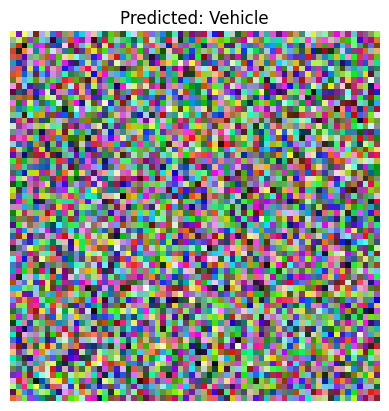

In [12]:
# ==========================================================
# AUTONOMOUS DRIVING OBJECT CLASSIFICATION
# COMPLETE SIMPLE PROJECT CODE
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os # Import os module for path operations

# ----------------------------------------------------------
# STEP 1: SETTINGS
# ----------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

BATCH_SIZE = 4
EPOCHS = 10
LEARNING_RATE = 0.001

# ----------------------------------------------------------
# STEP 2: IMAGE TRANSFORM
# Resize images + convert to tensor
# ----------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# ----------------------------------------------------------
# STEP 3: LOAD REAL IMAGE DATASET
# Folder names automatically become labels
# ----------------------------------------------------------

# Path to the dummy dataset
dataset_path = "/content/sample_data/Dataset"

# Remove .ipynb_checkpoints if it exists, as it can interfere with ImageFolder
ipynb_checkpoints_path = os.path.join(dataset_path, '.ipynb_checkpoints')
if os.path.exists(ipynb_checkpoints_path):
    import shutil
    shutil.rmtree(ipynb_checkpoints_path)
    print(f"Removed problematic directory: {ipynb_checkpoints_path}")

dataset = datasets.ImageFolder(dataset_path, transform=transform)

loader = DataLoader(dataset,
                    batch_size=BATCH_SIZE,
                    shuffle=True)

classes = dataset.classes
print("Classes:", classes)

# Dynamically set num_classes based on the actual dataset
num_classes_actual = len(classes)
print(f"Detected {num_classes_actual} classes from dataset.")

# ----------------------------------------------------------
# STEP 4: SIMPLE CNN MODEL
# ----------------------------------------------------------

class SimpleCNN(nn.Module):

    # Update __init__ to accept num_classes
    def __init__(self, num_classes_arg):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            # Use the passed num_classes_arg here
            nn.Linear(64, num_classes_arg) # Use dynamic num_classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.fc_layers(x)
        return x

# Instantiate model with the actual number of classes
model = SimpleCNN(num_classes_actual).to(DEVICE)

# ----------------------------------------------------------
# STEP 5: CROSS ENTROPY LOSS
# (Softmax included internally)
# ----------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ----------------------------------------------------------
# STEP 6: TRAINING LOOP
# OBJECTIVE = MINIMIZE LOSS
# ----------------------------------------------------------

print("\nTraining Started...\n")

for epoch in range(EPOCHS):

    total_loss = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        outputs = model(images)

        # Cross Entropy Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss = {total_loss:.4f}")

print("\nTraining Complete ✅")

# ----------------------------------------------------------
# STEP 7: CLASS PROBABILITY SCORES
# ----------------------------------------------------------

print("\nClass Probability Scores:\n")

with torch.no_grad():

    for images, labels in loader:

        images = images.to(DEVICE)

        logits = model(images)

        # Softmax \u2192 probabilities
        probabilities = torch.softmax(logits, dim=1)

        for i in range(len(images)):

            print(f"\nImage {i+1}")

            for j, cls in enumerate(classes):
                print(f"{cls}: {probabilities[i][j].item():.4f}")

        break   # show only one batch

# ----------------------------------------------------------
# STEP 8: VISUALIZE PREDICTION (OPTIONAL)
# ----------------------------------------------------------

def show_image(img_tensor, title):
    img = img_tensor.cpu().numpy().transpose((1,2,0))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()


with torch.no_grad():

    images, labels = next(iter(loader))
    images = images.to(DEVICE)

    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)

    _, predicted = torch.max(probs, 1);

    # show first image
    show_image(images[0], f"Predicted: {classes[predicted[0]]}")